In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import torch

In [3]:
words = open('names.txt', 'r').read().splitlines()

In [4]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
len(words)

32033

````markdown
# Understanding the Bigram Counting Loop with `"emma"`

Let's walk through exactly how the loop works using the name **"emma"** as an example.

Before the loop runs, the word is converted into a list of characters with special **Start** (`<S>`) and **End** (`<E>`) tokens:

```python
chs = ['<S>', 'e', 'm', 'm', 'a', '<E>']
```

---

## 1. Creating Character Pairs with `zip(chs, chs[1:])`

The expression

```python
zip(chs, chs[1:])
```

creates overlapping pairs of characters by aligning the list with a shifted version of itself.

### Original List

```python
['<S>', 'e', 'm', 'm', 'a', '<E>']
```

### Shifted List

```python
['e', 'm', 'm', 'a', '<E>']
```

### Resulting Pairs

```python
('<S>', 'e')
('e', 'm')
('m', 'm')
('m', 'a')
('a', '<E>')
```

These pairs represent transitions from one character to the next:

| Current Character | Next Character |
|------------------|----------------|
| `<S>` | `e` |
| `e` | `m` |
| `m` | `m` |
| `m` | `a` |
| `a` | `<E>` |

---

## 2. Unpacking Each Pair

The loop iterates through these pairs one at a time:

```python
for ch1, ch2 in zip(chs, chs[1:]):
```

For each iteration:

- `ch1` stores the current character
- `ch2` stores the next character

These two characters are then combined into a tuple:

```python
bigram = (ch1, ch2)
```

Examples:

```python
('<S>', 'e')
('e', 'm')
('m', 'm')
```

This tuple becomes the **dictionary key** that we want to count.

---

## 3. Counting with `b.get()`

The counting happens with:

```python
b[bigram] = b.get(bigram, 0) + 1
```

### What does `b.get(bigram, 0)` do?

It asks:

> "Does this bigram already exist in the dictionary?"

- **Yes** → return its current count.
- **No** → return `0`.

Then the code adds `1` and stores the updated value back into the dictionary.

---

## Step-by-Step Execution for `"emma"`

Starting with an empty dictionary:

```python
b = {}
```

### Iteration 1

```python
bigram = ('<S>', 'e')
```

```python
b = {
    ('<S>', 'e'): 1
}
```

---

### Iteration 2

```python
bigram = ('e', 'm')
```

```python
b = {
    ('<S>', 'e'): 1,
    ('e', 'm'): 1
}
```

---

### Iteration 3

```python
bigram = ('m', 'm')
```

```python
b = {
    ('<S>', 'e'): 1,
    ('e', 'm'): 1,
    ('m', 'm'): 1
}
```

---

### Iteration 4

```python
bigram = ('m', 'a')
```

```python
b = {
    ('<S>', 'e'): 1,
    ('e', 'm'): 1,
    ('m', 'm'): 1,
    ('m', 'a'): 1
}
```

---

### Iteration 5

```python
bigram = ('a', '<E>')
```

```python
b = {
    ('<S>', 'e'): 1,
    ('e', 'm'): 1,
    ('m', 'm'): 1,
    ('m', 'a'): 1,
    ('a', '<E>'): 1
}
```

---

## When a Bigram Appears Again

Suppose the next word in the dataset is **"emily"**.

One of its bigrams will be:

```python
('e', 'm')
```

This bigram already exists in the dictionary:

```python
b.get(('e', 'm'), 0)
```

returns:

```python
1
```

The code then increments the count:

```python
1 + 1 = 2
```

and updates the dictionary:

```python
b[('e', 'm')] = 2
```

Now the dictionary knows that the transition:

```python
'e' → 'm'
```

has been observed **twice** across the dataset.

---

## Key Idea

By repeatedly processing every word in the dataset, this loop builds a **frequency table of character transitions (bigrams)**.

For example:

```python
('e', 'm') → 2
('m', 'm') → 1
('m', 'a') → 1
```

These counts form the foundation of a **bigram language model**, which learns how likely one character is to follow another.
````


In [6]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [8]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [9]:
N = torch.zeros((28,28), dtype=torch.int32)

````markdown id="vocabmap01"
## Understanding the Vocabulary Mapping Code

This block of code creates a **two-way lookup table** (a mapping system). Neural networks cannot read characters like `"a"` or `"b"` directly—they can only process numbers. The purpose of this code is to find all the unique characters in the dataset and assign a unique integer to each one.

To see how it works, let's assume our entire dataset contains just two words:

```python
words = ['emma', 'mia']
```

---

### Line 1: Finding All Unique Characters

```python
chars = sorted(list(set(''.join(words))))
```

This line extracts the **alphabet** of the dataset. It executes from the inside out:

#### Step 1: Join all words into one string

```python
''.join(words)
```

```python
'emmamia'
```

#### Step 2: Remove duplicate characters

```python
set('emmamia')
```

```python
{'e', 'm', 'a', 'i'}
```

A Python `set` automatically keeps only unique values.

#### Step 3: Convert the set back into a list

```python
list({'e', 'm', 'a', 'i'})
```

```python
['e', 'm', 'a', 'i']
```

#### Step 4: Sort alphabetically

```python
sorted(...)
```

```python
['a', 'e', 'i', 'm']
```

Final result:

```python
chars = ['a', 'e', 'i', 'm']
```

---

### Line 2: Creating the String-to-Integer Mapping (`stoi`)

```python
stoi = {s:i+1 for i,s in enumerate(chars)}
```

This is a **dictionary comprehension**.

`enumerate(chars)` loops through the list and provides:

- `i` → the index
- `s` → the character

Since the code reserves `0` for a special token, it stores `i + 1` instead of `i`.

#### Step-by-Step Iteration

| i | s | Added to Dictionary |
|---|---|---|
| 0 | `'a'` | `'a': 1` |
| 1 | `'e'` | `'e': 2` |
| 2 | `'i'` | `'i': 3` |
| 3 | `'m'` | `'m': 4` |

Result:

```python
stoi = {
    'a': 1,
    'e': 2,
    'i': 3,
    'm': 4
}
```

---

### Line 3: Adding the Special Token

```python
stoi['.'] = 0
```

If a key doesn't already exist in a dictionary, Python simply adds it.

Instead of using separate start (`<S>`) and end (`<E>`) tokens, this implementation uses a single special character:

```python
'.'
```

and assigns it the value:

```python
0
```

Updated dictionary:

```python
stoi = {
    'a': 1,
    'e': 2,
    'i': 3,
    'm': 4,
    '.': 0
}
```

Now the neural network can represent every character as an integer:

| Character | Integer |
|-----------|----------|
| `.` | 0 |
| `a` | 1 |
| `e` | 2 |
| `i` | 3 |
| `m` | 4 |

---

### Line 4: Creating the Integer-to-String Mapping (`itos`)

```python
itos = {i:s for s,i in stoi.items()}
```

This creates the **reverse mapping**.

Why is this needed?

During generation, the neural network will output numbers such as:

```python
[2, 4, 4, 1]
```

To convert those numbers back into readable text, we need a way to map integers back to characters.

The expression:

```python
stoi.items()
```

returns:

```python
('a', 1)
('e', 2)
('i', 3)
('m', 4)
('.', 0)
```

The dictionary comprehension simply flips each pair.

#### Step-by-Step Iteration

| Original Pair | New Pair |
|--------------|----------|
| `'a': 1` | `1: 'a'` |
| `'e': 2` | `2: 'e'` |
| `'i': 3` | `3: 'i'` |
| `'m': 4` | `4: 'm'` |
| `'.': 0` | `0: '.'` |

Result:

```python
itos = {
    1: 'a',
    2: 'e',
    3: 'i',
    4: 'm',
    0: '.'
}
```

---

### Final Mappings

#### String → Integer (`stoi`)

```python
{
    '.': 0,
    'a': 1,
    'e': 2,
    'i': 3,
    'm': 4
}
```

#### Integer → String (`itos`)

```python
{
    0: '.',
    1: 'a',
    2: 'e',
    3: 'i',
    4: 'm'
}
```

### Key Idea

The two dictionaries work together:

```python
stoi['m']  # → 4
```

and

```python
itos[4]    # → 'm'
```

This allows the neural network to convert characters into numbers for training and then convert numbers back into characters when generating new names.
````


In [10]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [11]:
b = {}
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

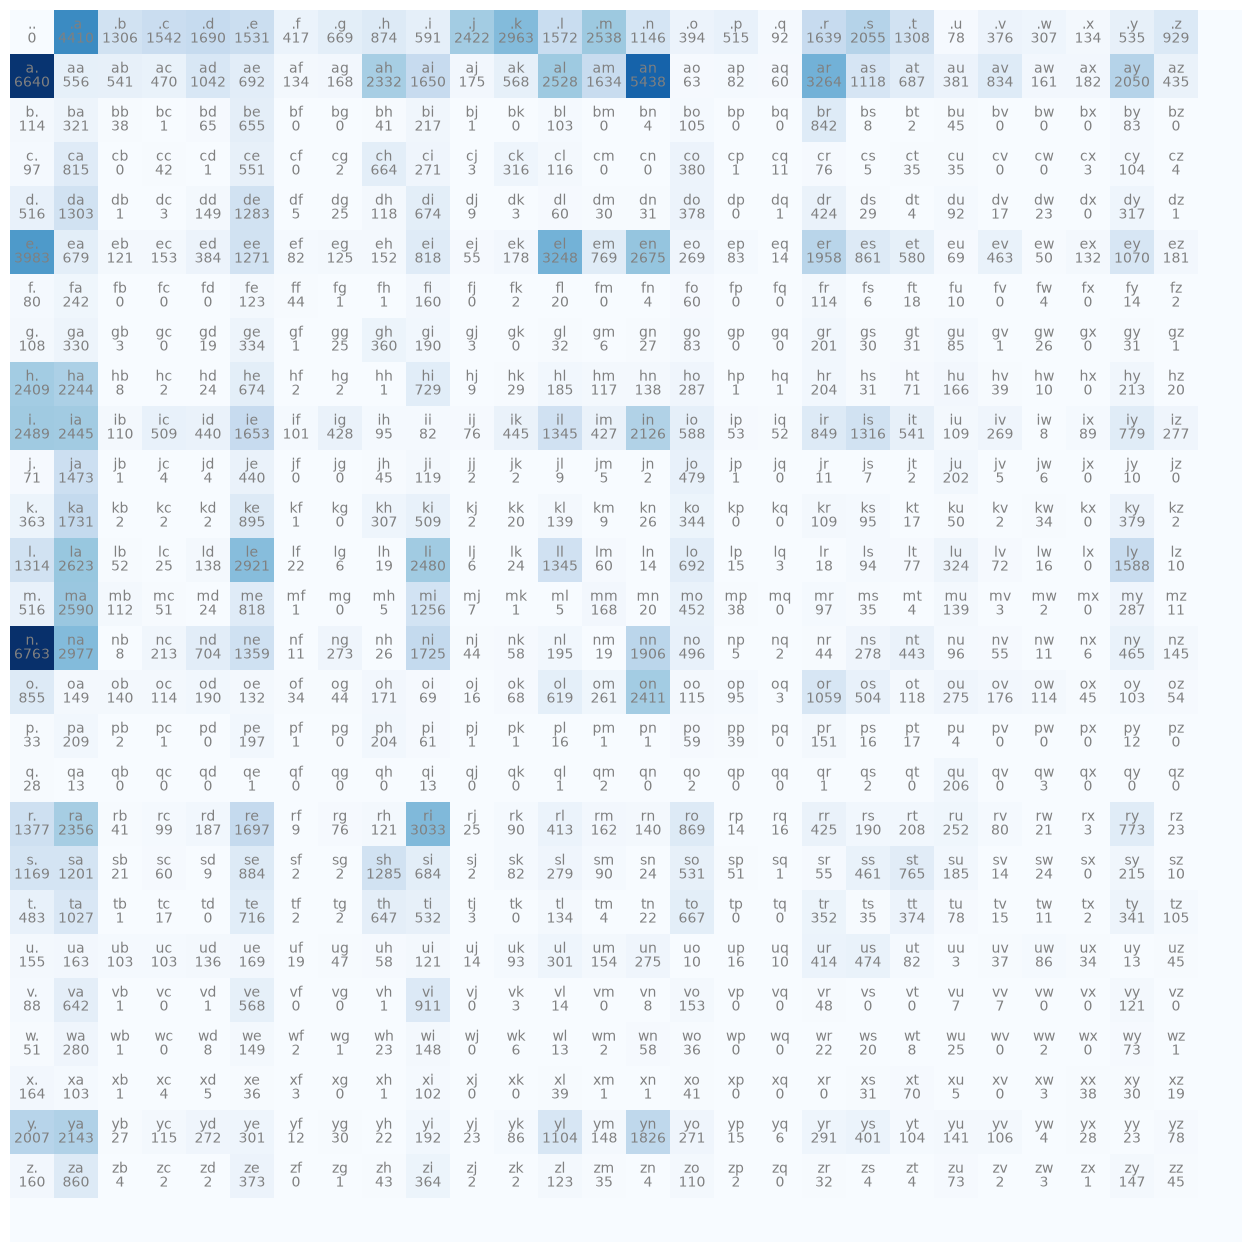

In [12]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
    plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [13]:
N[0, :]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929,    0], dtype=torch.int32)

In [ ]:
p = N[0].float() #reaches into your big 27x27 transition matrix and grabs the very first row (the row for the start token .). It contains the raw counts of how many times every letter started a word.
p = p / p.sum() # p.sum()is the total number of words in your dataset. By dividing every single character's count by the total, you convert raw counts into probabilities
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290,
        0.0000])

In [15]:
g = torch.Generator().manual_seed(214783647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.1904, 0.5401, 0.2694])

## Understanding `torch.multinomial()`

Let's use the exact example from the notebook:

```python
p = torch.tensor([0.1904, 0.5401, 0.2694])
```

This tensor represents a probability distribution over three possible outcomes:

| Index | Probability | Approximate Chance |
|---------|------------|-------------------|
| 0 | 0.1904 | 19% |
| 1 | 0.5401 | 54% |
| 2 | 0.2694 | 27% |

Notice that Index **1** has the highest probability, meaning it is the most likely outcome to be selected.

---

### The Intuition: Rolling a Weighted Die

You can think of this probability distribution as a special three-sided die:

- Side **0** appears 19% of the time
- Side **1** appears 54% of the time
- Side **2** appears 27% of the time

When you run:

```python
torch.multinomial(p, num_samples=100, replacement=True)
```

you are effectively telling PyTorch:

> "Roll this weighted three-sided die 100 times and record the result of each roll."

The output will be a tensor containing 100 integers, where each integer is either `0`, `1`, or `2`.

---

## Understanding the Parameters

### `p`

```python
p = torch.tensor([0.1904, 0.5401, 0.2694])
```

This is the probability distribution that controls how likely each outcome is to be selected.

Before using `torch.multinomial()`, these probabilities should sum to `1.0`:

```python
0.1904 + 0.5401 + 0.2694 ≈ 1.0
```

This is why you'll often see:

```python
p = p / p.sum()
```

which normalizes the values into a valid probability distribution.

---

### `num_samples=100`

```python
num_samples=100
```

This specifies how many random draws to perform.

In this example:

```python
torch.multinomial(p, num_samples=100, replacement=True)
```

PyTorch will make **100 independent selections** and return all of them in a tensor.

---

### `replacement=True`

```python
replacement=True
```

This means that after an outcome is selected, it is immediately placed back into the pool before the next draw.

Think of it like drawing a colored ball from a bag:

1. Draw a ball.
2. Write down its color.
3. Put it back.
4. Shake the bag.
5. Draw again.

Because the ball is returned each time, the probabilities never change.

As a result, the same index can appear repeatedly:

```python
tensor([1, 1, 2, 1, 0, 1, 1, 2, ...])
```

If `replacement=False`, once an index is selected, it cannot be selected again.

---

## What Does the Output Mean?

Suppose the output begins like this:

```python
tensor([1, 2, 1, 1, 0, 1, 2, 1, 1, 1])
```

Each number is simply the index that was chosen during that particular draw.

For example:

| Draw | Selected Index |
|--------|---------------|
| 1 | 1 |
| 2 | 2 |
| 3 | 1 |
| 4 | 1 |
| 5 | 0 |

Since Index **1** has a probability of **54%**, it occupies more than half of the probability distribution.

Therefore, over many draws, you should expect to see:

- More `1`s than anything else
- A moderate number of `2`s
- The fewest `0`s

---

## Why Doesn't It Always Pick Index 1?

Even though Index 1 is the most likely outcome, the process is still random.

For a single draw:

```python
torch.multinomial(p, num_samples=1, replacement=True)
```

all three outcomes remain possible:

```python
0
1
2
```

Index 1 is simply more likely to occur.

This is similar to flipping a biased coin:

- Heads: 90%
- Tails: 10%

You can still get tails occasionally—the probability is lower, not zero.

---

## Expected Results After 100 Draws

Given:

```python
p = [0.1904, 0.5401, 0.2694]
```

you would expect roughly:

| Index | Probability | Expected Count (100 Draws) |
|---------|------------|---------------------------|
| 0 | 19% | ~19 times |
| 1 | 54% | ~54 times |
| 2 | 27% | ~27 times |

The actual counts will vary because of randomness:

```python
Index 0 → 17
Index 1 → 58
Index 2 → 25
```

or

```python
Index 0 → 21
Index 1 → 52
Index 2 → 27
```

Both are completely normal.

As the number of samples grows larger (e.g., 1,000 or 10,000 draws), the observed frequencies get closer and closer to the original probabilities.

---

### Key Idea

`torch.multinomial()` performs **random sampling according to a probability distribution**.

```python
torch.multinomial(p, num_samples=100, replacement=True)
```

does **not** always choose the most probable option. Instead, it chooses outcomes randomly while respecting the probabilities in `p`.

In our example:

```python
p = [0.1904, 0.5401, 0.2694]
```

Index `1` appears most often because it is the most likely outcome, but all three indices remain possible on every draw.

In [16]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([2, 2, 2, 1, 0, 0, 1, 1, 2, 2, 1, 1, 2, 0, 1, 2, 1, 2, 0, 0, 2, 2, 1, 0,
        1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 2, 1, 1, 2, 1, 2, 2, 2,
        1, 1, 1, 1, 0, 0, 2, 1, 1, 2, 1, 1, 1, 2, 0, 2, 2, 1, 2, 2, 1, 1, 1, 1,
        2, 1, 1, 1, 1, 0, 1, 2, 2, 1, 2, 2, 0, 1, 0, 0, 1, 1, 2, 0, 0, 1, 2, 0,
        1, 1, 1, 0])